**Importing all necessary libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


**1.Loading Data set**

In [ ]:
df=pd.read_csv("data.csv",encoding="unicode_escape")
df

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,01-02-1990
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,01-02-1990
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,01-02-1990
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,01-03-1990
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,01-03-1990
...,...,...,...,...,...,...,...,...,...,...,...,...,...
435737,SAMP,24-12-2015,West Bengal,ULUBERIA,West Bengal State Pollution Control Board,RIRUO,22.0,50.0,143.0,NaN,"Inside Rampal Industries,ULUBERIA",NaN,24-12-2015
435738,SAMP,29-12-2015,West Bengal,ULUBERIA,West Bengal State Pollution Control Board,RIRUO,20.0,46.0,171.0,NaN,"Inside Rampal Industries,ULUBERIA",NaN,29-12-2015
435739,NaN,NaN,andaman-and-nicobar-islands,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
435740,NaN,NaN,Lakshadweep,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**2.Data Preprocessing**

In [ ]:
#Print first 5 columns of dataset
df.head()

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,01-02-1990
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,01-02-1990
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,01-02-1990
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,01-03-1990
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,01-03-1990


In [ ]:
#Print last 5 columns
df.tail(5)

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
435737,SAMP,24-12-2015,West Bengal,ULUBERIA,West Bengal State Pollution Control Board,RIRUO,22.0,50.0,143.0,NaN,"Inside Rampal Industries,ULUBERIA",NaN,24-12-2015
435738,SAMP,29-12-2015,West Bengal,ULUBERIA,West Bengal State Pollution Control Board,RIRUO,20.0,46.0,171.0,NaN,"Inside Rampal Industries,ULUBERIA",NaN,29-12-2015
435739,NaN,NaN,andaman-and-nicobar-islands,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
435740,NaN,NaN,Lakshadweep,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
435741,NaN,NaN,Tripura,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Number of rows and columns
df.shape

(435742, 13)

In [ ]:
#Total number of elements
df.size

5664646

In [ ]:
#checking the overall information about the data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     291665 non-null  object 
 1   sampling_date                435739 non-null  object 
 2   state                        435742 non-null  object 
 3   location                     435739 non-null  object 
 4   agency                       286261 non-null  object 
 5   type                         430349 non-null  object 
 6   so2                          401096 non-null  float64
 7   no2                          419509 non-null  float64
 8   rspm                         395520 non-null  float64
 9   spm                          198355 non-null  float64
 10  location_monitoring_station  408251 non-null  object 
 11  pm2_5                        9314 non-null    float64
 12  date                         435735 non-null  object 
dtyp

In [ ]:
#chcking null values
df.isnull().sum()

stn_code                       144077
sampling_date                       3
state                               0
location                            3
agency                         149481
type                             5393
so2                             34646
no2                             16233
rspm                            40222
spm                            237387
location_monitoring_station     27491
pm2_5                          426428
date                                7
dtype: int64

In [ ]:
#descriptive satistics of numerical columns
df.describe()

,so2,no2,rspm,spm,pm2_5
count,401096.000000,419509.000000,395520.000000,198355.000000,9314.000000
mean,10.829414,25.809623,108.832784,220.783480,40.791467
std,11.177187,18.503086,74.872430,151.395457,30.832525
min,0.000000,0.000000,0.000000,0.000000,3.000000
25%,5.000000,14.000000,56.000000,111.000000,24.000000
50%,8.000000,22.000000,90.000000,187.000000,32.000000
75%,13.700000,32.200000,142.000000,296.000000,46.000000
max,909.000000,876.000000,6307.033333,3380.000000,504.000000


In [ ]:
#To display all the unique values in the column
df.nunique()

stn_code                        803
sampling_date                  5071
state                            37
location                        304
agency                           64
type                             10
so2                            4197
no2                            6864
rspm                           6065
spm                            6668
location_monitoring_station     991
pm2_5                           433
date                           5067
dtype: int64

In [ ]:
#Columns present in the dataset
df.columns

Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')

# **2.1. Exploratory Data Analysis**

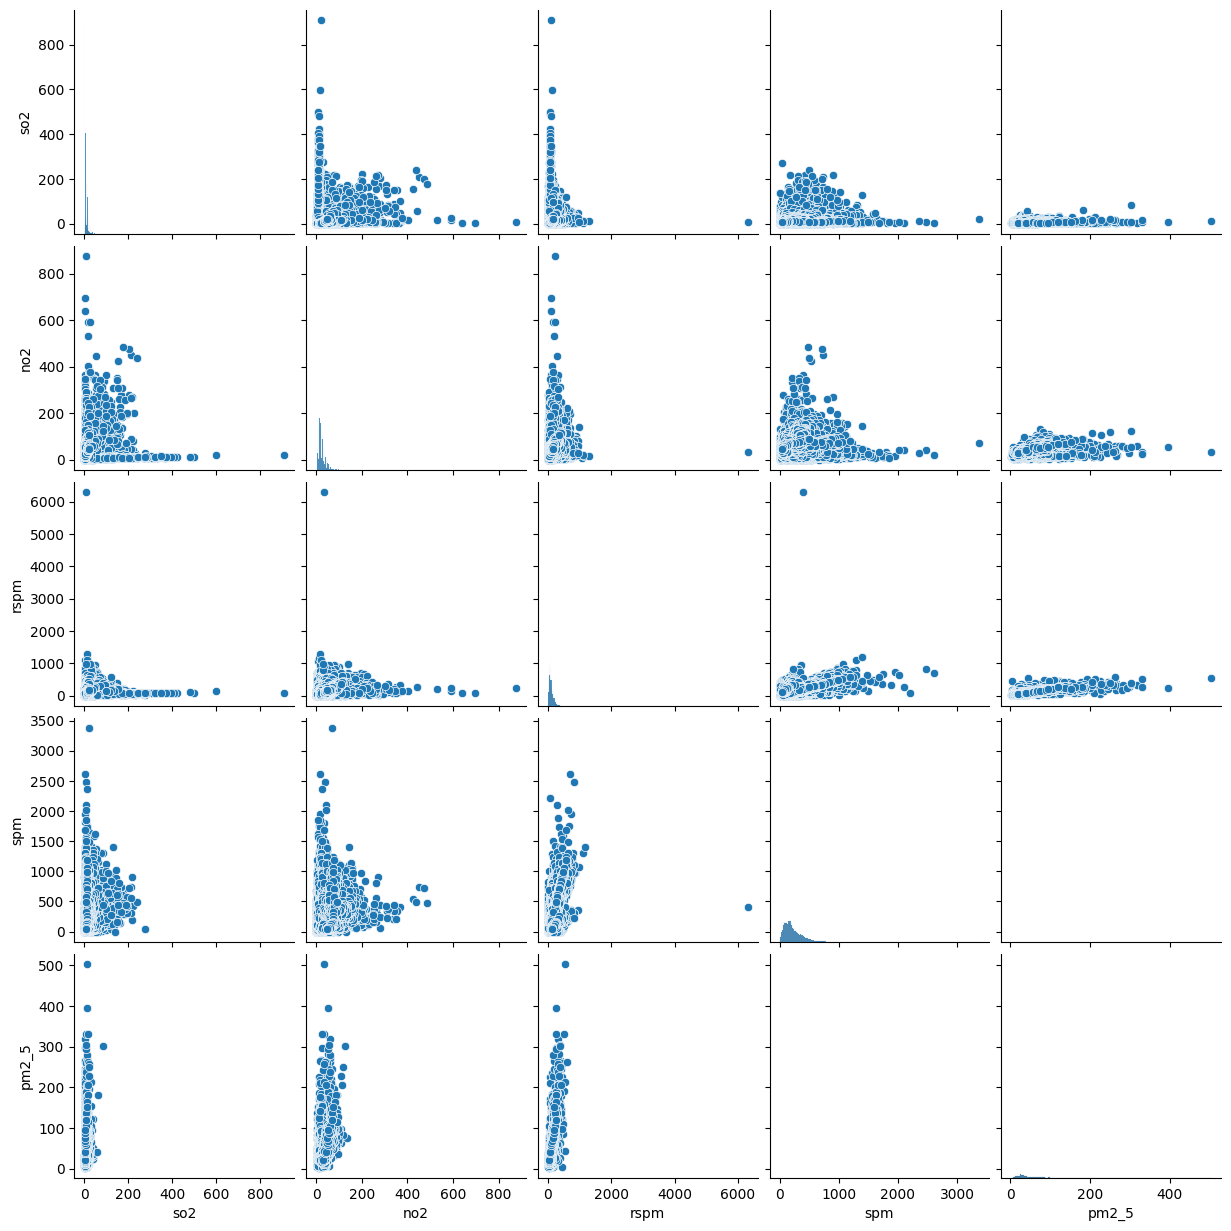

In [ ]:
sns.pairplot(data=df)

In [ ]:
df['state'].value_counts()

Maharashtra                    60384
Uttar Pradesh                  42816
Andhra Pradesh                 26368
Punjab                         25634
Rajasthan                      25589
Kerala                         24728
Himachal Pradesh               22896
West Bengal                    22463
Gujarat                        21279
Tamil Nadu                     20597
Madhya Pradesh                 19920
Assam                          19361
Odisha                         19279
Karnataka                      17119
Delhi                           8551
Chandigarh                      8520
Chhattisgarh                    7831
Goa                             6206
Jharkhand                       5968
Mizoram                         5338
Telangana                       3978
Meghalaya                       3853
Puducherry                      3785
Haryana                         3420
Nagaland                        2463
Bihar                           2275
Uttarakhand                     1961
J

[]

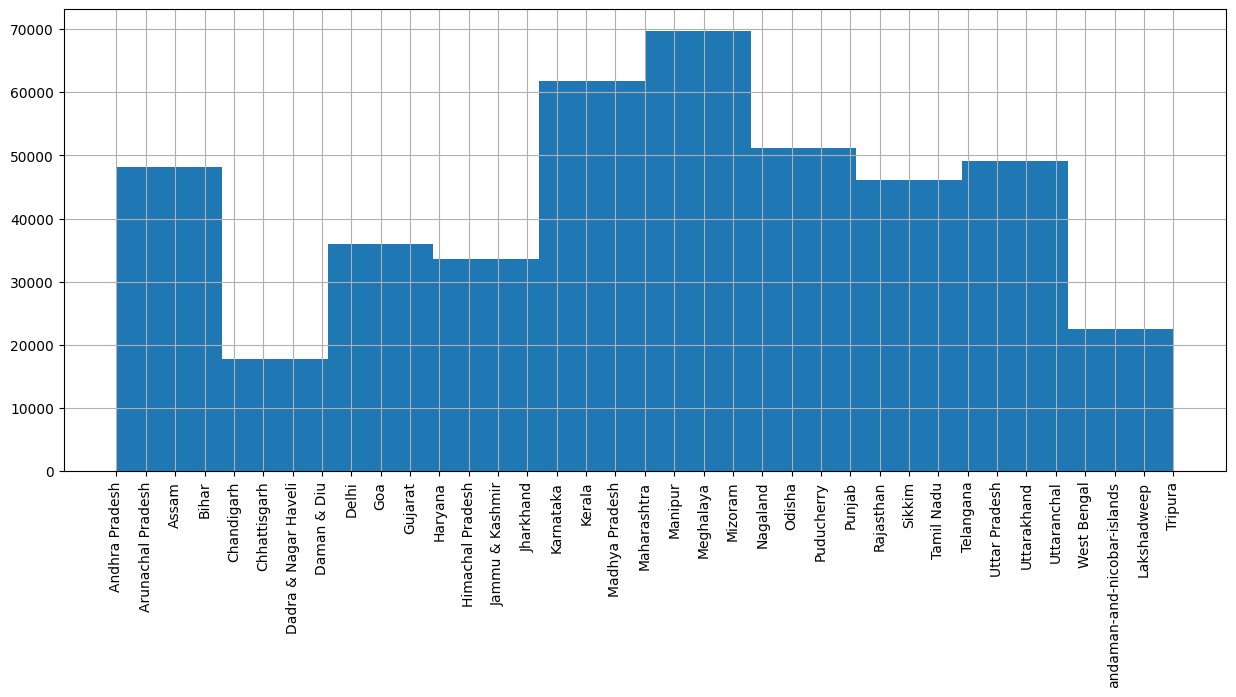

In [ ]:
#visualization shows the frequency of states
plt.figure(figsize=(15,6))
plt.xticks(rotation=90)
df.state.hist()
plt.xlabel=('state')
plt.ylabel=('Frequencies')
plt.plot()

In [ ]:
#shows the count of  value present in the type column
df['type'].value_counts()

Residential, Rural and other Areas    179014
Industrial Area                        96091
Residential and others                 86791
Industrial Areas                       51747
Sensitive Area                          8980
Sensitive Areas                         5536
RIRUO                                   1304
Sensitive                                495
Industrial                               233
Residential                              158
Name: type, dtype: int64

[]

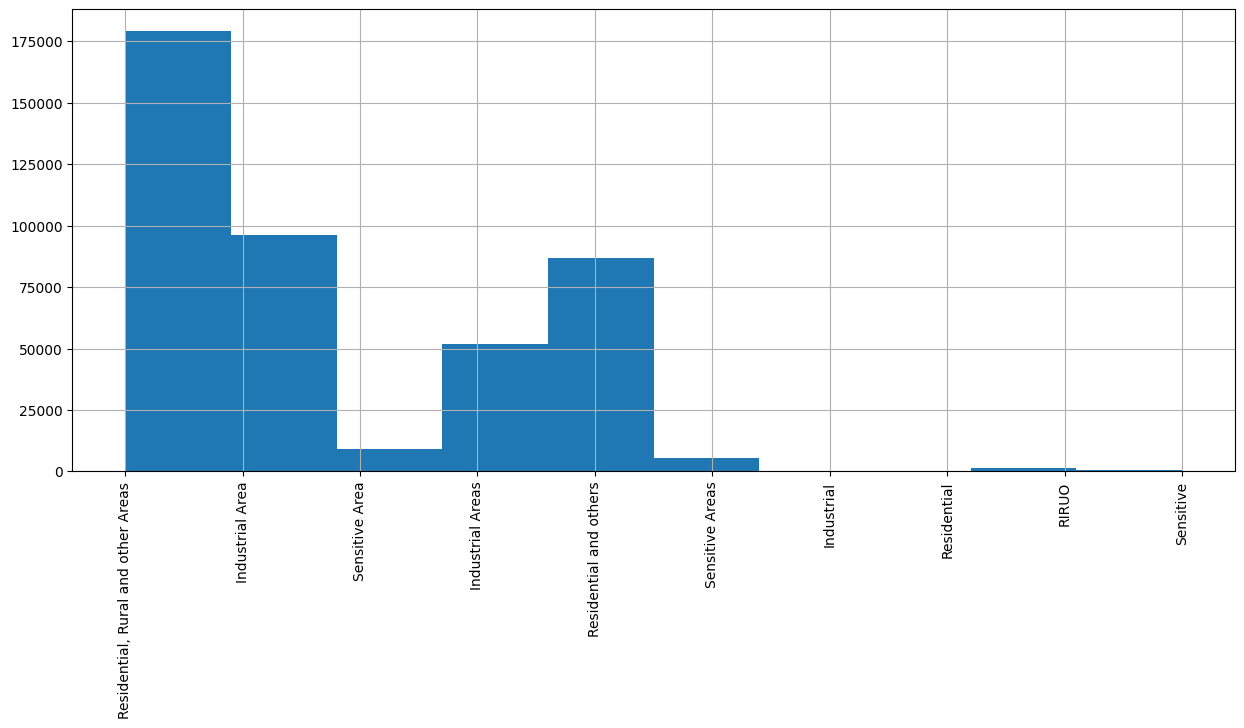

In [ ]:
#visualization shows the types present in the dataset
plt.figure(figsize=(15,6))
plt.xticks(rotation=90)
df.type.hist()
plt.xlabel=('type')
plt.ylabel=('Frequencies')
plt.plot()

In [ ]:
#shows the count of  value present in the agency column
df['agency'].value_counts()

Maharashtra State Pollution Control Board                                 27857
Uttar Pradesh State Pollution Control Board                               22686
Andhra Pradesh State Pollution Control Board                              19139
Himachal Pradesh State Environment Proection & Pollution Control Board    15287
Punjab State Pollution Control Board                                      15232
                                                                          ...  
Arunachal Pradesh State Pollution Control Board                              90
TNPC                                                                         82
RPCB                                                                         63
VRCE                                                                         61
RJPB                                                                         53
Name: agency, Length: 64, dtype: int64

[]

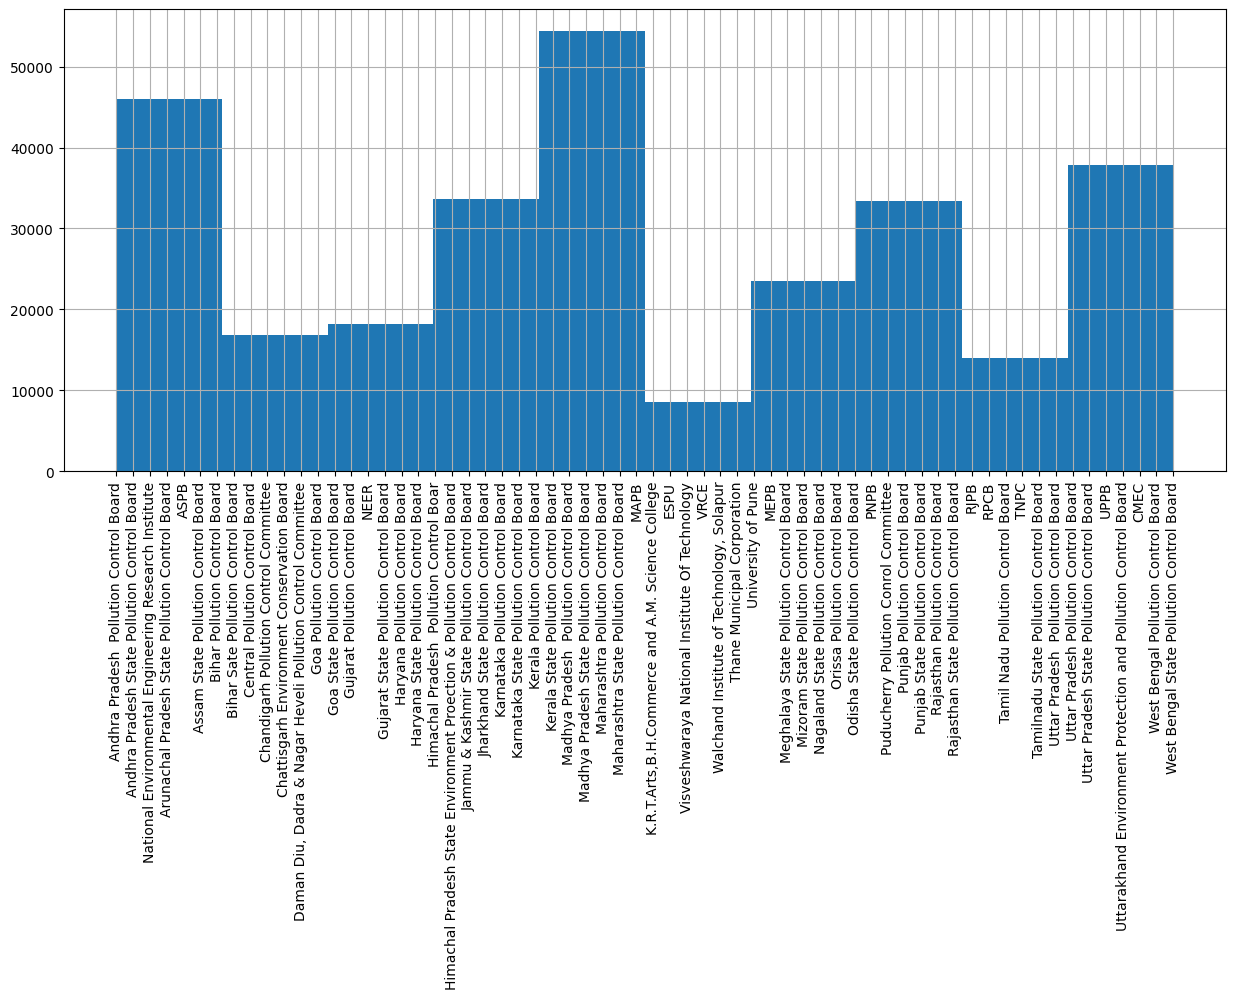

In [ ]:
#visualization shows the count of agency
plt.figure(figsize=(15,6))
plt.xticks(rotation=90)
df.agency.hist()
plt.xlabel=('agency')
plt.ylabel=('Frequencies')
plt.plot()

<Axes: xlabel='state', ylabel='so2'>

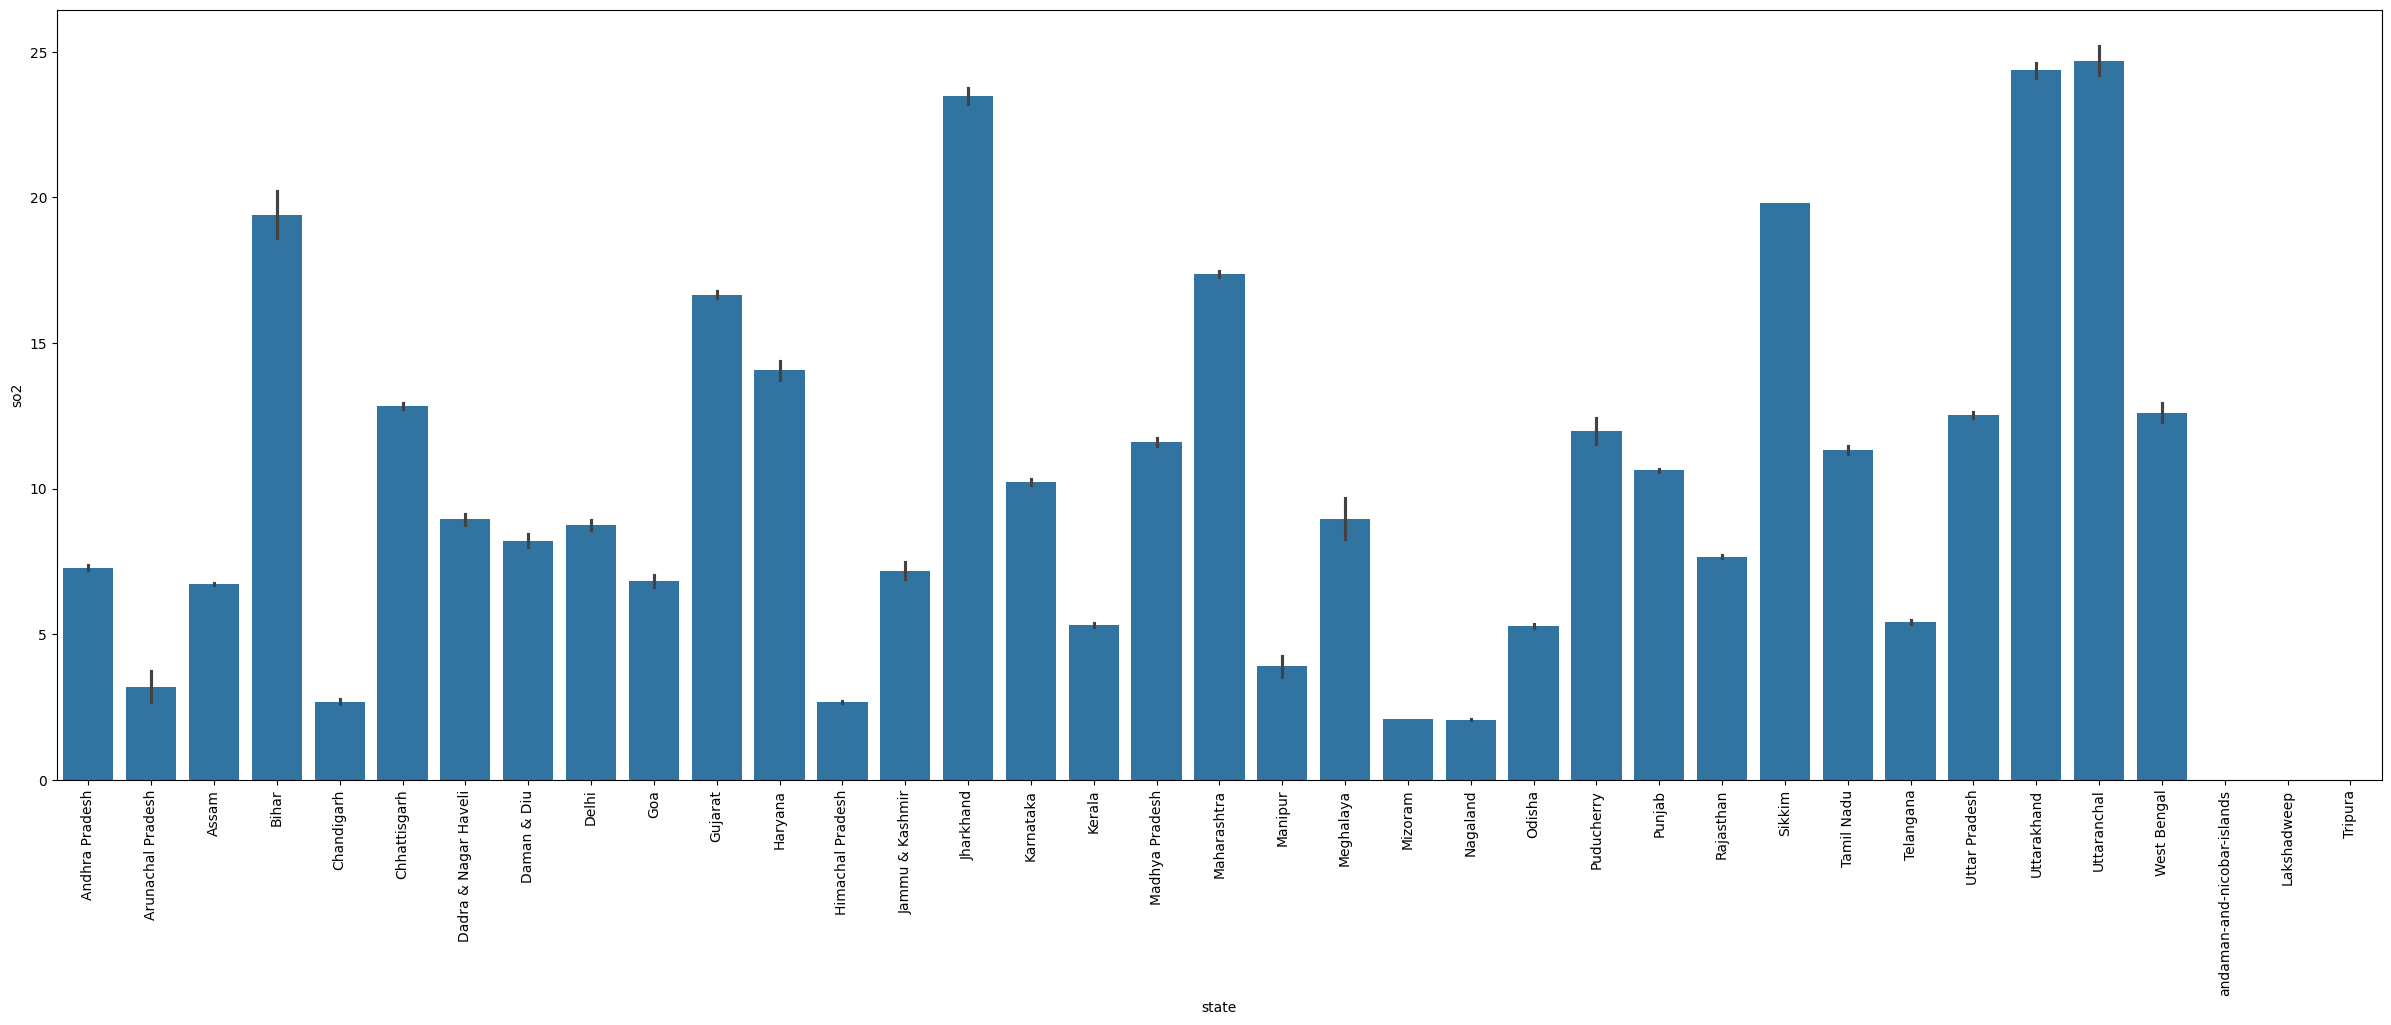

In [ ]:
 #This visualisation shows the name of  state having higher so2 level in the air
plt.figure(figsize=(30,10))
plt.xticks(rotation=90)
sns.barplot(x='state',y='so2',data=df)

<Axes: xlabel='state', ylabel='no2'>

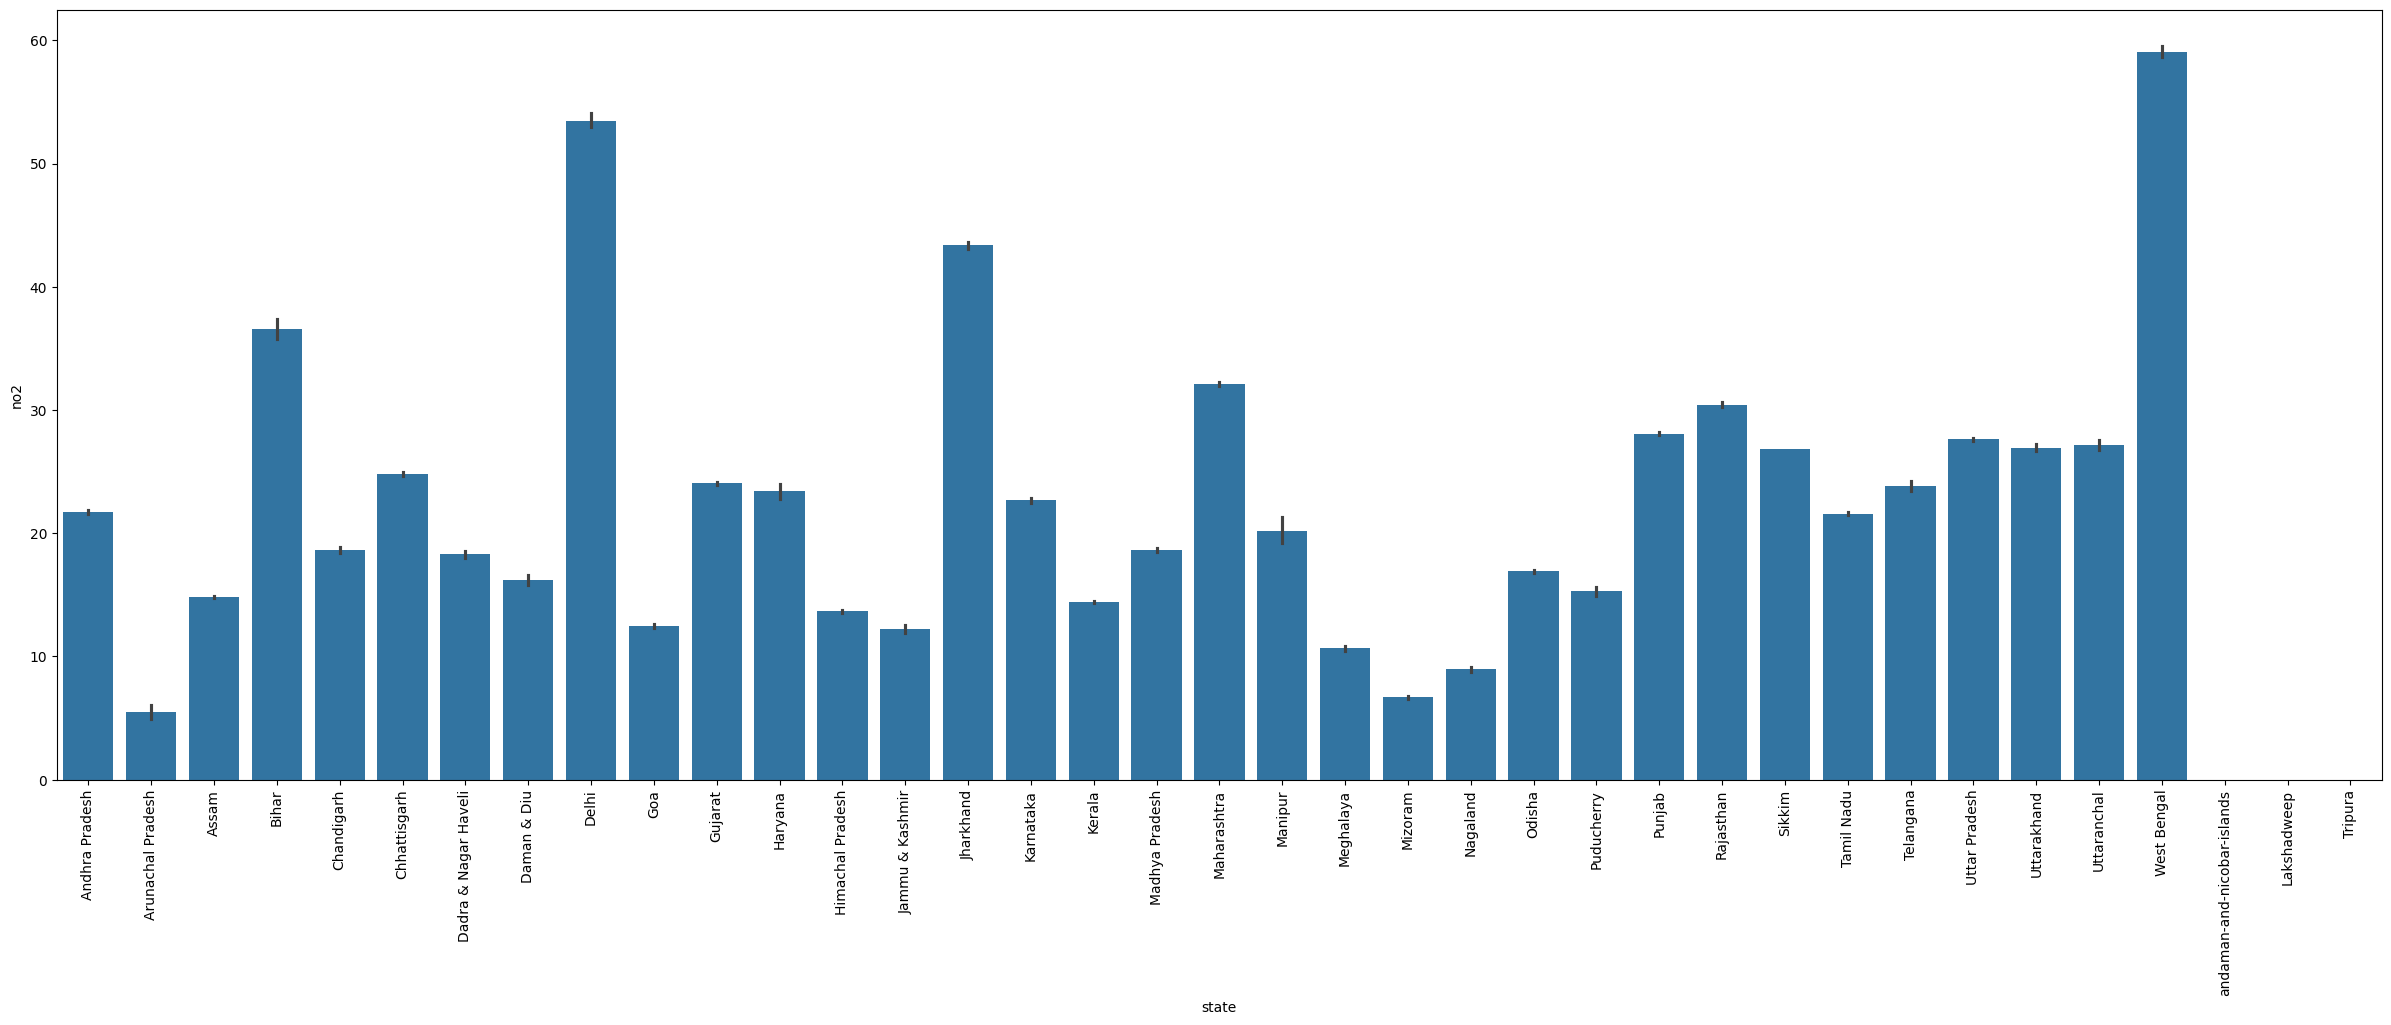

In [ ]:
 #This visualisation shows the name of  state having higher NO2 level in the air==>Delhi is highest and ArunachalP is lowest
plt.figure(figsize=(30,10))
plt.xticks(rotation=90)
sns.barplot(x='state',y='no2',data=df)

<Axes: xlabel='state', ylabel='rspm'>

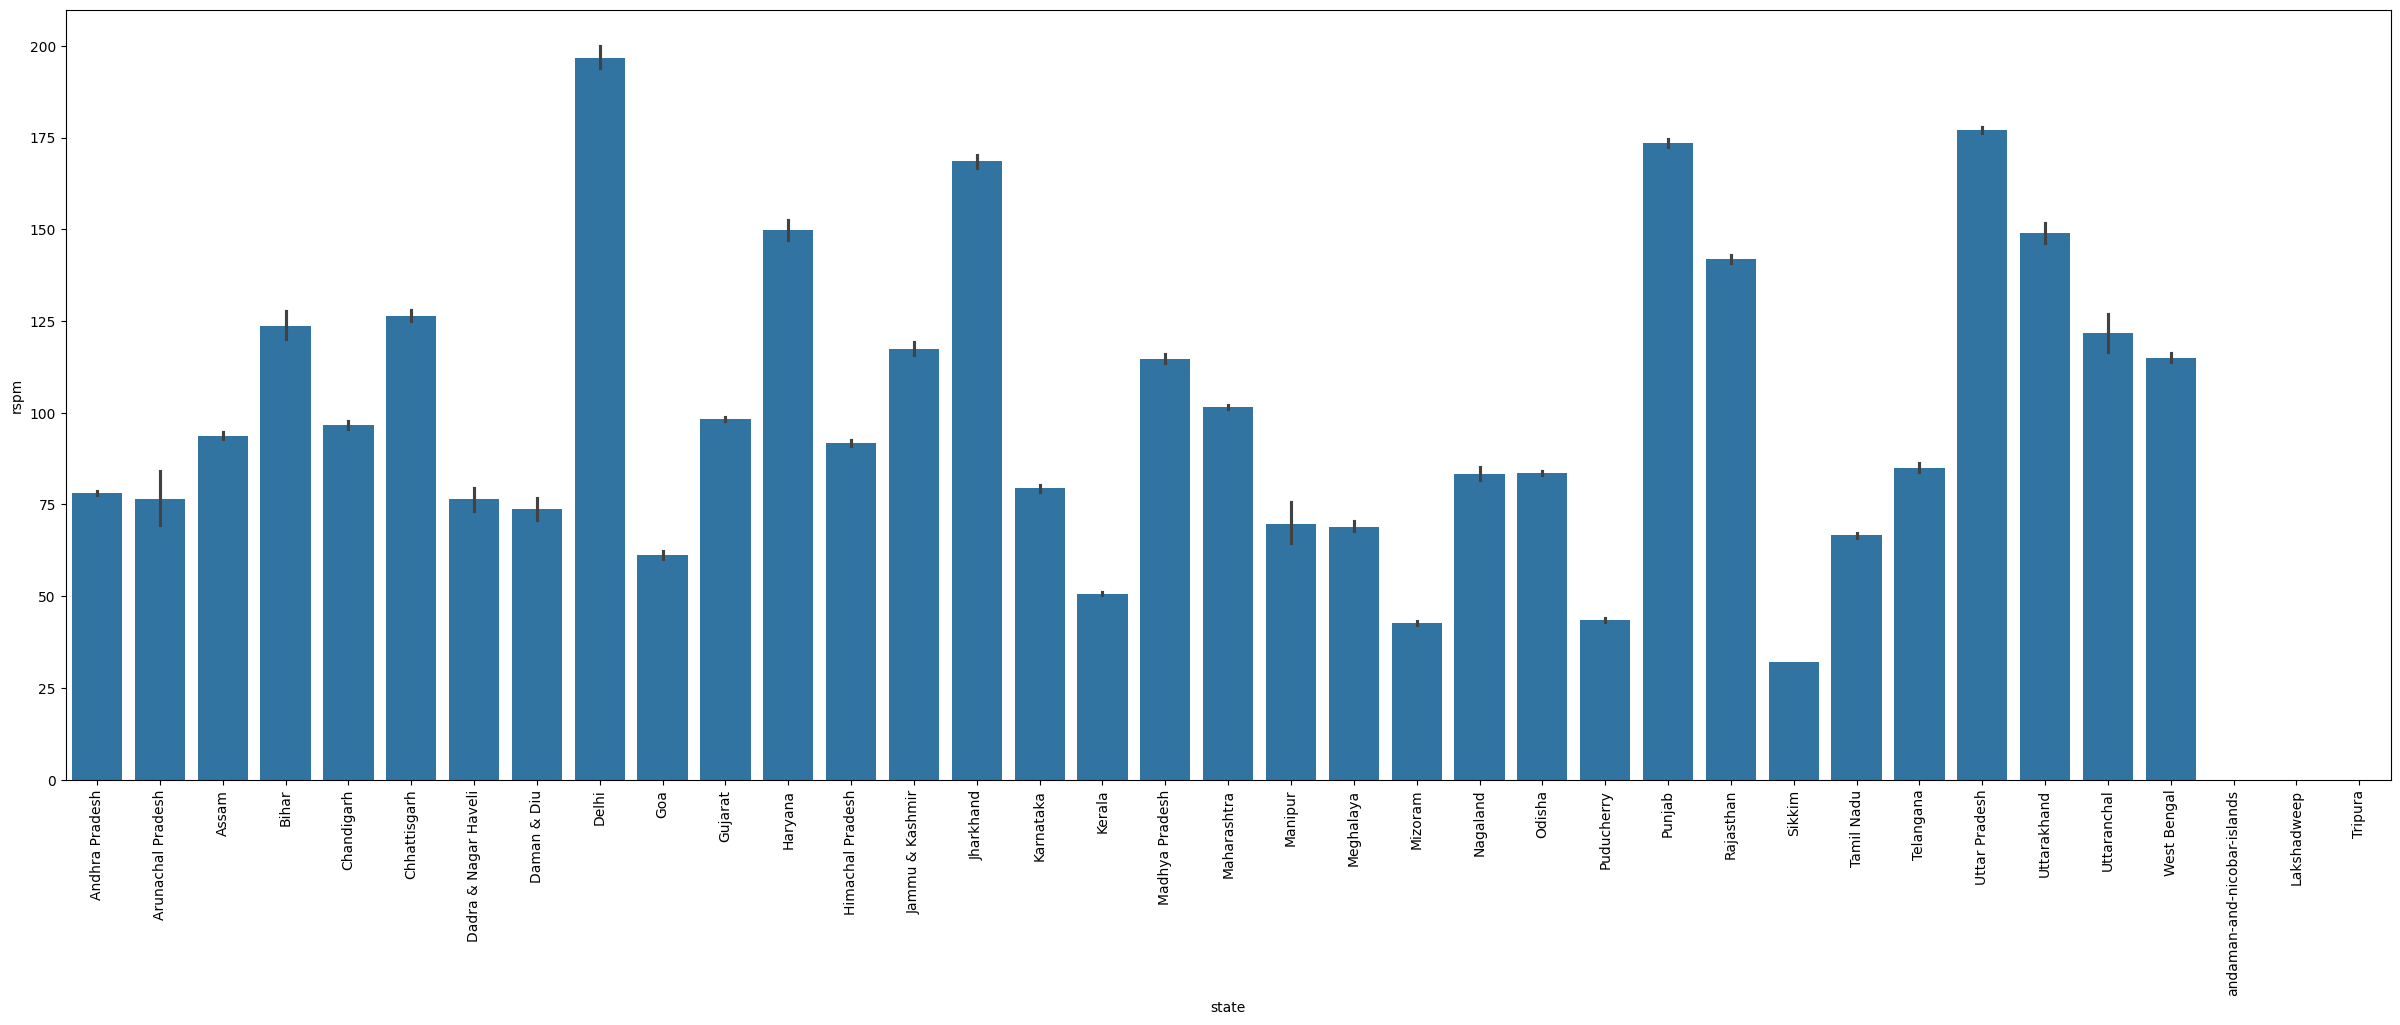

In [ ]:
 #This visualisation shows the name of  state having higher Rspm level in the air
 #Highest is Delhi, Lowest is Madhya Pradesh
plt.figure(figsize=(30,10))
plt.xticks(rotation=90)
sns.barplot(x='state',y='rspm',data=df)

<Axes: xlabel='state', ylabel='spm'>

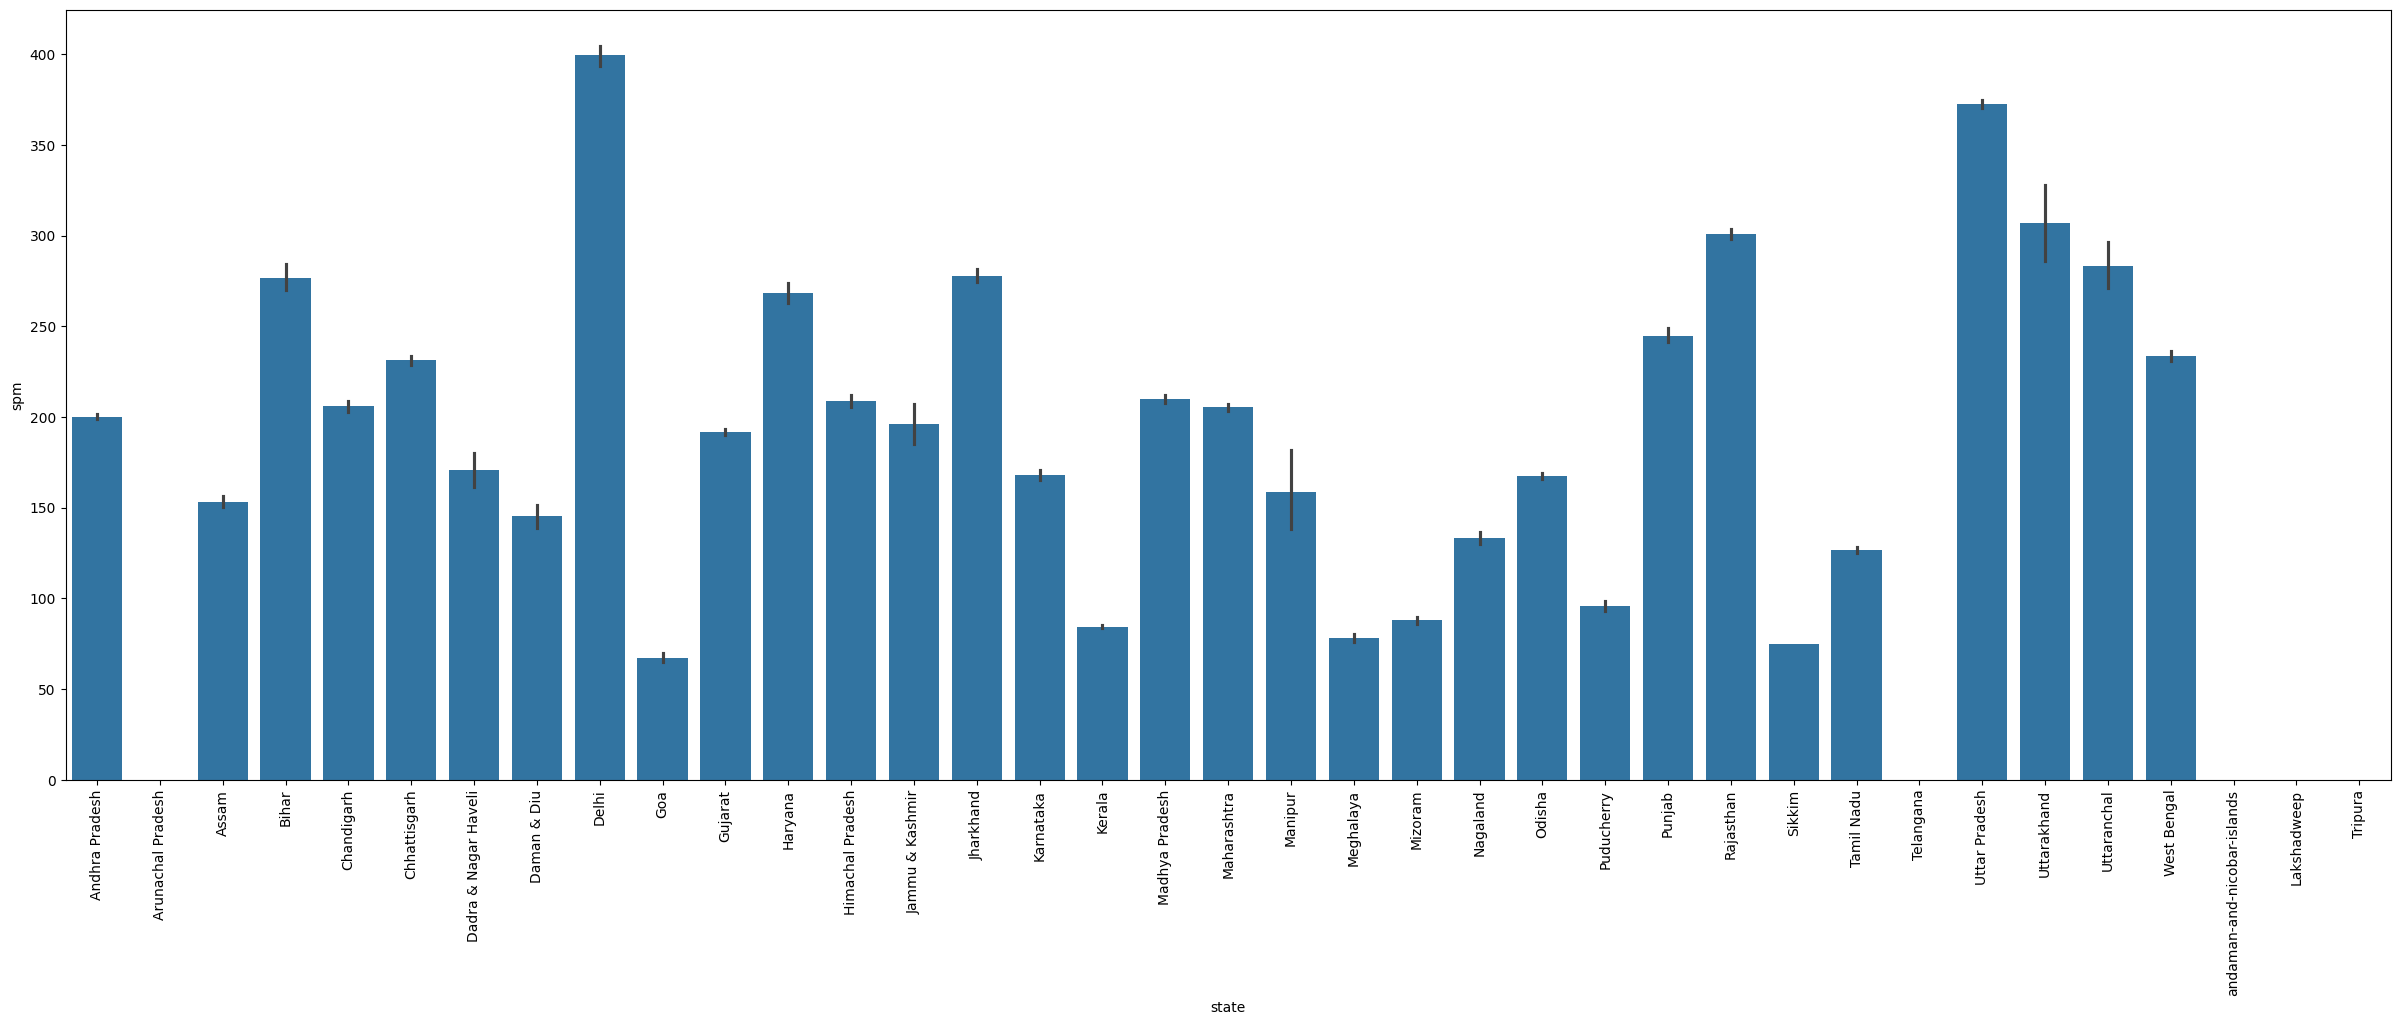

In [ ]:
 #This visualisation shows the name of  state having higher spm level in the air
 #highest=Delhi ,Lowest=Goa
plt.figure(figsize=(30,10))
plt.xticks(rotation=90)
sns.barplot(x='state',y='spm',data=df)

<Axes: xlabel='state', ylabel='pm2_5'>

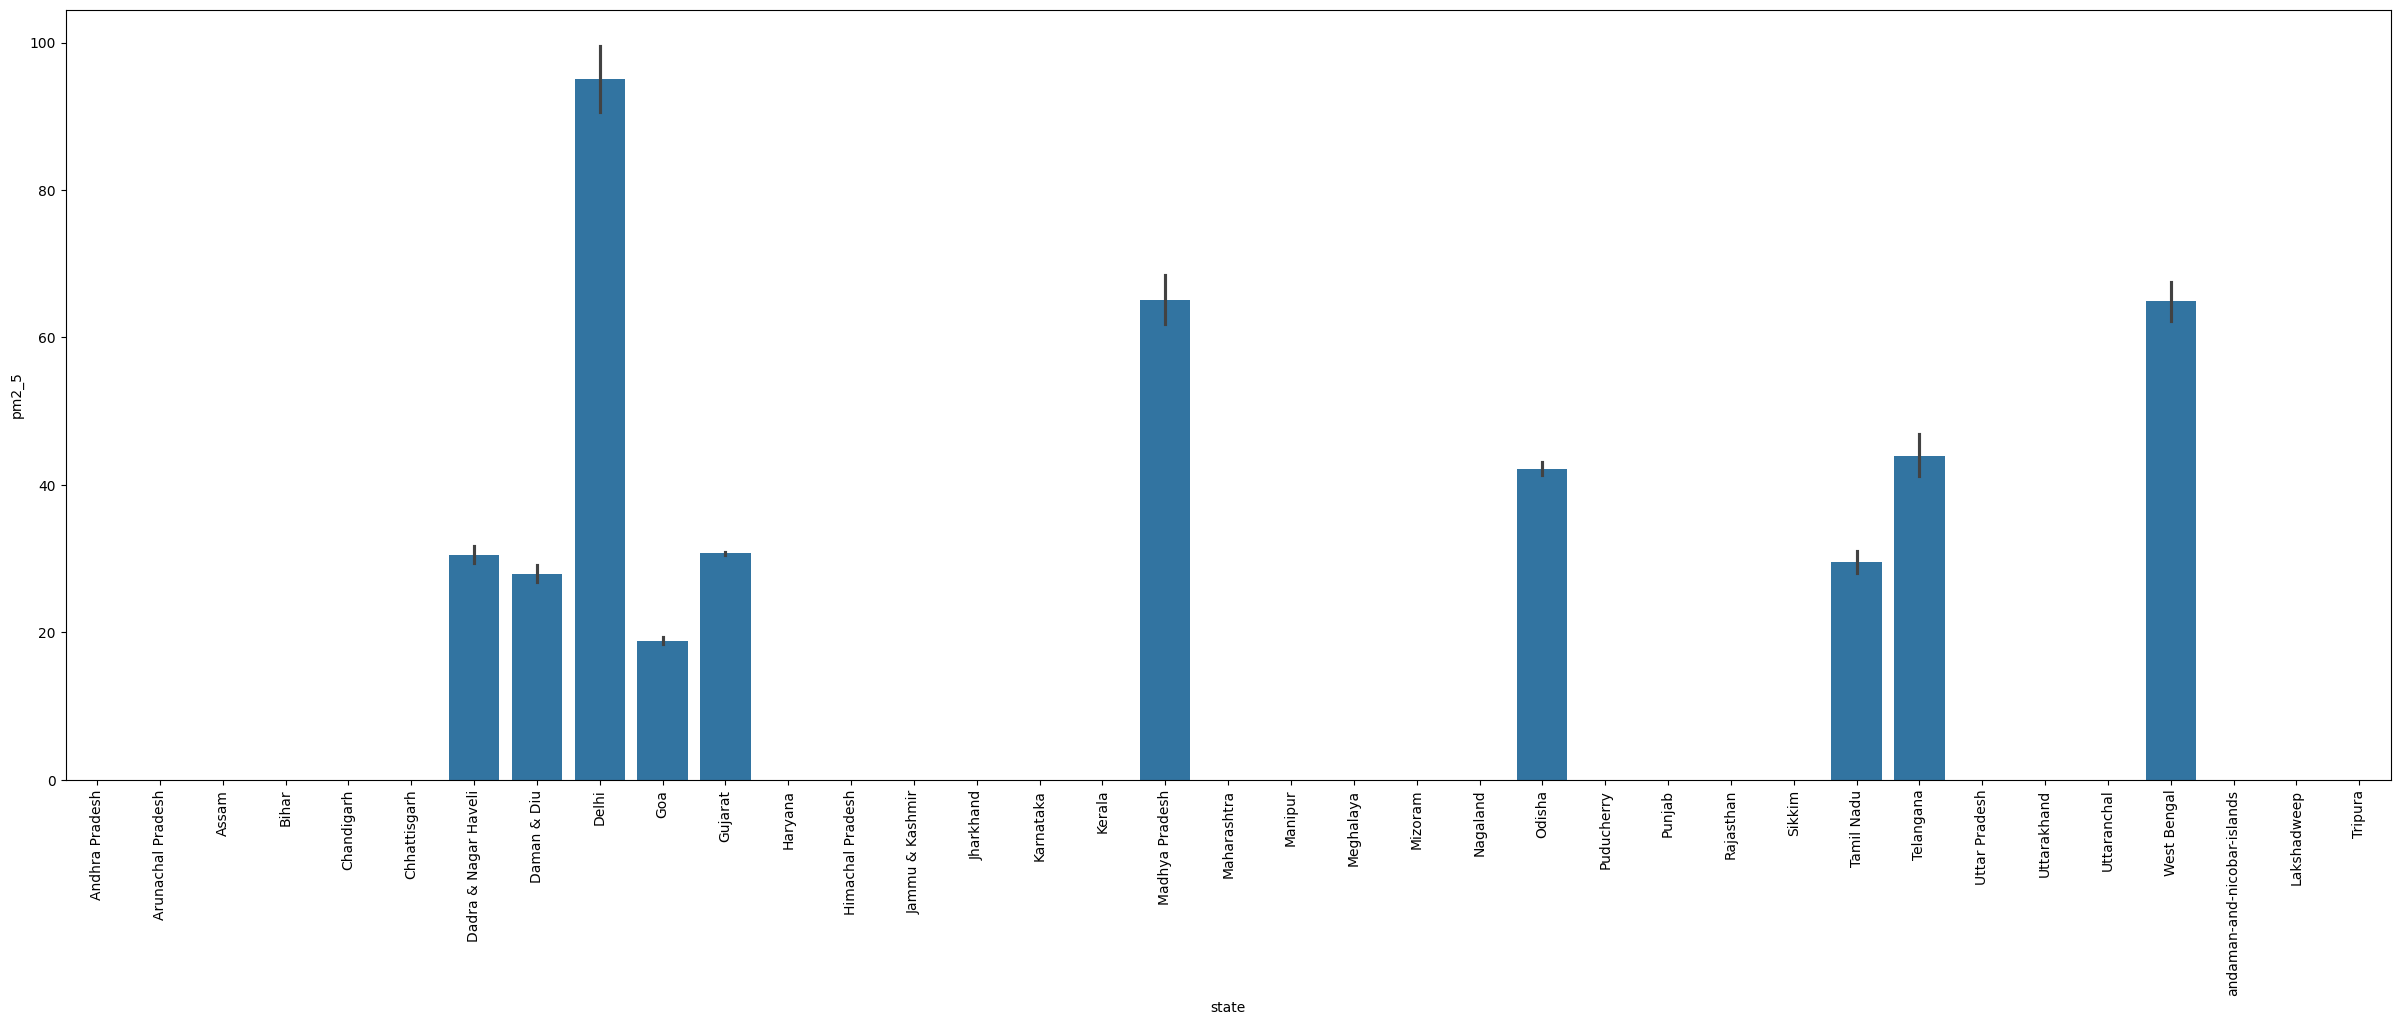

In [ ]:
 #This visualisation shows the name of  state having higher pm2_5 level in the air
 #highest=Delhi,lowest=Goa
plt.figure(figsize=(30,10))
plt.xticks(rotation=90)
sns.barplot(x='state',y='pm2_5',data=df)

# FEATURE ENGINEERING

In [ ]:
#Droping unnecessary columns
df.drop(['agency'],axis=1,inplace=True)


In [ ]:
df.drop(['stn_code'],axis=1,inplace=True)
df.drop(['date'],axis=1,inplace=True)
df.drop(['sampling_date'],axis=1,inplace=True)
df.drop(['location_monitoring_station'],axis=1,inplace=True)

In [ ]:
df.isnull().sum()

state            0
location         3
type          5393
so2          34646
no2          16233
rspm         40222
spm         237387
pm2_5       426428
dtype: int64

In [ ]:
df['location']=df['location'].fillna(df['location'].mode()[0])
df['type']=df['type'].fillna(df['type'].mode()[0])

In [ ]:
df.fillna(0,inplace=True)

# FUNCTIONS TO CALCULATE SO2,NO2,RSPM,SPM INDIVIDUAL POLLUTANT

In [ ]:
def cal_SOi(so2):
    si=0
    if(so2 <= 40):
      si=so2*(50 / 40)
    elif (so2>40 and so2<=80):
      si=50 + (so2 - 40) * (50 / 40)
    elif (so2>80 and so2<=380):
      si=100+ (so2 -80) * (100 / 300)
    elif (so2>380 and so2<=800):
      si=200 + (so2 -380) * (100 / 420)
    elif (so2>800 and so2<=1600):
      si=300 + (so2 - 800) * (100 / 800)
    elif(so2>1600):
      si=400 +(so2-1600)*(100/800)
    return si
df['SOi']=df['so2'].apply(cal_SOi)
data=df[['so2','SOi']]
data.head()




,so2,SOi
0,4.8,6.000
1,3.1,3.875
2,6.2,7.750
3,6.3,7.875
4,4.7,5.875


In [ ]:
def cal_NOi(no2):
    ni=0
    if(no2 <= 40):
      ni=no2*(50 / 40)
    elif (no2>40 and no2<=80):
      ni=50 + (no2 - 40) * (50 / 40)
    elif (no2>80 and no2<=180):
      ni=100+ (no2 -80) * (100 / 100)
    elif (no2>180 and no2<=280):
      ni=200 + (no2 -180) * (100 / 100)
    elif (no2>280 and no2<=400):
      ni=300 + (no2 - 280) * (100 / 120)
    else:
       ni=400+(no2-400)*(100/120)
    return ni
df['NOi']=df['no2'].apply(cal_NOi)
data=df[['no2','NOi']]
data.head()




,no2,NOi
0,17.4,21.750
1,7.0,8.750
2,28.5,35.625
3,14.7,18.375
4,7.5,9.375


Calculating the individual pollutant index for rspm

In [ ]:
def cal_RSPMI(rspm):
    rpi=0
    if(rpi<=30):
      rpi=rpi*(50 / 30)
    elif (rpi>30 and rpi<=60):
      rpi=50 + (rpi - 30) * (50 / 30)
    elif (rpi>60 and rpi<=90):
      rpi=100+ (rpi -60) * (100 / 30)
    elif (rpi>90 and rpi<=120):
      rpi=200 + (rpi -90) * (100 / 30)
    elif (rpi>120 and rpi<=250):
      rpi=300 + (rpi - 120) * (100 / 130)
    else:
       rpi=400+(rpi-250)*(100/130)
    return rpi
df['Rpi']=df['rspm'].apply(cal_RSPMI)
data=df[['rspm','Rpi']]
data.head()




,rspm,Rpi
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


In [ ]:
def cal_SPMi(spm):
    spi=0
    if(spi<=50):
      spi=spm*(50 / 50)
    elif (spm>50 and spm<=100):
      spi=50 + (spm - 50) * (50 / 50)
    elif (spm>100 and spm<=250):
      spi=100+ (spm -100) * (100 / 150)
    elif (spm>250 and spm<=350):
      spi=200 + (spm -250) * (100 / 100)
    elif (spm>350 and spm<=430):
      spi=300 + (spm - 350) * (100 / 80)
    else:
       spi=400+(spm-250)*(100/430)
    return spi
df['SPMi']=df['spm'].apply(cal_SPMi)
data=df[['spm','SPMi']]
data.head()




,spm,SPMi
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


# FUNCTION TO CALCULATE AQI

In [ ]:
def cal_aqi(si,ni,rspmi,spmi):
  aqi=0
  if(si>ni and si>rspmi and si>spmi):
    aqi=si
  if(ni>si and ni>rspmi and ni>spmi):
    aqi=ni
  if(rspmi>si and rspmi>ni and rspmi>spmi):
    aqi=rspmi
  if(spmi>si and spmi>ni and spmi>rspmi):
    aqi=spmi
  return aqi
df['AQI']=df.apply(lambda x:cal_aqi(x['SOi'],x['NOi'],x['Rpi'],x['SPMi']),axis=1)
data=df[['state','SOi','NOi','Rpi','SPMi','AQI']]
data.head()


,state,SOi,NOi,Rpi,SPMi,AQI
0,Andhra Pradesh,6.000,21.750,0.0,0.0,21.750
1,Andhra Pradesh,3.875,8.750,0.0,0.0,8.750
2,Andhra Pradesh,7.750,35.625,0.0,0.0,35.625
3,Andhra Pradesh,7.875,18.375,0.0,0.0,18.375
4,Andhra Pradesh,5.875,9.375,0.0,0.0,9.375


FUNCTION TO CALCULATE AQI-RANGE

In [ ]:
def AQI_Range(x):
  if x<=50:
    return "Good"
  elif x>50 and x<=100:
    return "Moderate"
  elif x>100 and x<=200:
    return "Poor"
  elif x>200 and x<=300:
    return "Unhealthy"
  elif x>300 and x<=400:
    return "Very unhealthy"
  elif x>400:
    return "Hazardous"
df['AQI_Range'] = df['AQI'].apply(AQI_Range)
df.head()


,state,location,type,so2,no2,rspm,spm,pm2_5,SOi,NOi,Rpi,SPMi,AQI,AQI_Range
0,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",4.8,17.4,0.0,0.0,0.0,6.000,21.750,0.0,0.0,21.750,Good
1,Andhra Pradesh,Hyderabad,Industrial Area,3.1,7.0,0.0,0.0,0.0,3.875,8.750,0.0,0.0,8.750,Good
2,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.2,28.5,0.0,0.0,0.0,7.750,35.625,0.0,0.0,35.625,Good
3,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.3,14.7,0.0,0.0,0.0,7.875,18.375,0.0,0.0,18.375,Good
4,Andhra Pradesh,Hyderabad,Industrial Area,4.7,7.5,0.0,0.0,0.0,5.875,9.375,0.0,0.0,9.375,Good


SPLITTING THE DATASET INTO DEPENDANT AND INDEPENDANT VARIABLE

In [ ]:
x=df[['SOi','NOi','Rpi','SPMi']]
y=df[['AQI']]
x.head()

,SOi,NOi,Rpi,SPMi
0,6.000,21.750,0.0,0.0
1,3.875,8.750,0.0,0.0
2,7.750,35.625,0.0,0.0
3,7.875,18.375,0.0,0.0
4,5.875,9.375,0.0,0.0


In [ ]:
y.head()

,AQI
0,21.750
1,8.750
2,35.625
3,18.375
4,9.375


## SPLITING DATASET INTO TRAINING DATA AND TESTING DATA

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=70)

## REGRESSION MODELS TO FIND AQI

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
print(model.score(x_test,y_test))


0.9895770483262581


In [ ]:
from sklearn.tree import DecisionTreeRegressor
model1=DecisionTreeRegressor()
model1.fit(x_train,y_train)
print(model1.score(x_test,y_test))

0.9998115955428226


In [ ]:
from sklearn.ensemble import RandomForestRegressor
model2=RandomForestRegressor(n_estimators=100)
model2.fit(x_train,y_train)
print(model2.score(x_test,y_test))

0.9998123773947403


In [ ]:
y_pred=model2.predict(x_test)
y_pred

array([ 17.5 ,  41.25,  31.25, ..., 182.  , 171.  , 329.  ])

# PERFORMANCE EVALUATION

In [ ]:
from sklearn.metrics import mean_absolute_error
print("mean absolute  error=",mean_absolute_error(y_test,y_pred))

mean absolute  error= 0.04601255640213321


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
print("mean absolute percentage erroe=",mean_absolute_percentage_error(y_pred,y_test))

mean absolute percentage erroe= 968943912301.8844


In [ ]:
from sklearn.metrics import mean_squared_error
print("mean squared error=",mean_squared_error(y_test,y_pred))

mean squared error= 3.6817816925342615


In [ ]:
z= mean_squared_error(y_test,y_pred)
print(np.sqrt(z))

1.9187969388484707


In [ ]:
from sklearn.metrics import r2_score
print("r2 score=",r2_score(y_pred,y_test))

r2 score= 0.9998121947259778


### CLASSIFICATION

In [ ]:
#splitting values into independend and dependant variables
x1=df[['SOi','NOi','Rpi','SPMi']]
y1=df[['AQI_Range']]
y1.head()

,AQI_Range
0,Good
1,Good
2,Good
3,Good
4,Good


### SPLITTING DATASET VALUES INTO TRAING AND TESTING

In [ ]:
x_train1,x_test1,y_train1,y_test1=train_test_split(x1,y1,test_size=0.3,random_state=70)

# CLASSIFICATION MODELS TO FIND AQI_RANGE

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtc= DecisionTreeClassifier()
dtc.fit(x_train1,y_train1)
print(dtc.score(x_test1,y_test1))

0.9998087559190043


In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train1,y_train1)
print(lr.score(x_test1,y_test1))

0.665590599970931


In [ ]:
from sklearn.svm import SVC
mod=SVC()
mod.fit(x_train1,y_train1)
print(mod.score(x_test1,y_test1))



0.993069314504716


In [ ]:
y_pre=dtc.predict(x_test1)
y_pre

array(['Good', 'Good', 'Good', ..., 'Hazardous', 'Moderate', 'Good'],
      dtype=object)

# checking real time predictions

In [ ]:
dtc.predict([[2,7,44,37.16]])

array(['Good'], dtype=object)

In [ ]:
dtc.predict([[727,327.55,78.2,100]])

array(['Unhealthy'], dtype=object)

In [ ]:
dtc.predict([[2,45.8,37,32]])

array(['Good'], dtype=object)

PERFORMANCE EVALUATION

In [ ]:
from sklearn.metrics import accuracy_score,classification_report
report=classification_report(y_pre,y_test1)
print(report)

                precision    recall  f1-score   support

          Good       1.00      1.00      1.00     65981
     Hazardous       1.00      1.00      1.00      7127
      Moderate       1.00      1.00      1.00     16987
          Poor       1.00      1.00      1.00     20648
     Unhealthy       1.00      1.00      1.00     12701
Very unhealthy       1.00      1.00      1.00      7279

      accuracy                           1.00    130723
     macro avg       1.00      1.00      1.00    130723
  weighted avg       1.00      1.00      1.00    130723



In [ ]:
score=accuracy_score(y_pre,y_test1)
score

0.9998087559190043